In [525]:
import pandas as pd
import numpy as np


In [526]:
df = pd.read_csv("C:/Users/criss/Downloads/ONINE_FOOD_DELIVERY_ANALYSIS.csv")
df

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST3722,NaN,NaN,Mumbai,NaN,RES295,Restaurant_500,Arabian,6/10/2024,...,132.0,Card,Delivered,NaN,DP835,2.0,4.0,Weekday,True,0.17
99996,ORD099997,CUST6158,NaN,Male,Mumbai,East,RES157,Restaurant_458,Arabian,4/22/2024,...,1078.0,NaN,Delivered,NaN,DP476,4.0,3.5,Weekday,False,-0.15
99997,ORD099998,CUST2155,NaN,NaN,Delhi,East,RES287,Restaurant_273,NaN,2/23/2024,...,NaN,COD,Cancelled,NaN,DP577,2.0,4.0,Weekday,True,0.47
99998,ORD099999,CUST3015,NaN,Female,Delhi,North,RES491,Restaurant_241,NaN,12/10/2024,...,NaN,NaN,Delivered,NaN,DP896,NaN,4.3,Weekday,NaN,0.44


In [527]:
#Checking rows and columns
print(df.shape)


(100000, 25)


In [528]:
#Checking duplicates
df.duplicated().sum()

np.int64(0)

In [529]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   object 
 4   City                 83274 non-null   object 
 5   Area                 83315 non-null   object 
 6   Restaurant_ID        100000 non-null  object 
 7   Restaurant_Name      100000 non-null  object 
 8   Cuisine_Type         83115 non-null   object 
 9   Order_Date           98986 non-null   object 
 10  Order_Time           98002 non-null   object 
 11  Delivery_Time_Min    66641 non-null   float64
 12  Distance_km          66530 non-null   float64
 13  Order_Value          66673 non-null   float64
 14  Discount_Applied     83285 non-null   float64
 15  Final_Amount      

In [530]:
#Checking only null columns
null_columns = df.isna().sum()
null_columns = null_columns[null_columns > 0]

result = pd.DataFrame({
    "null_columns" : null_columns,
    "Data_type" : df[null_columns.index].dtypes
})

print(result)


                     null_columns Data_type
Customer_Age                50093   float64
Customer_Gender             24856    object
City                        16726    object
Area                        16685    object
Cuisine_Type                16885    object
Order_Date                   1014    object
Order_Time                   1998    object
Delivery_Time_Min           33359   float64
Distance_km                 33470   float64
Order_Value                 33327   float64
Discount_Applied            16715   float64
Final_Amount                55697   float64
Payment_Mode                19911    object
Cancellation_Reason         90969    object
Delivery_Rating             16523   float64
Peak_Hour                   32962    object


In [531]:
df.select_dtypes(include= object).columns

Index(['Order_ID', 'Customer_ID', 'Customer_Gender', 'City', 'Area',
       'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type', 'Order_Date',
       'Order_Time', 'Payment_Mode', 'Order_Status', 'Cancellation_Reason',
       'Delivery_Partner_ID', 'Order_Day', 'Peak_Hour'],
      dtype='object')

DATA CLEANING


In [532]:
#Customer_Gender
df.groupby("Customer_ID")["Customer_Gender"].unique()

Customer_ID
CUST1000    [Female, Male, nan, Other]
CUST1001    [Male, nan, Other, Female]
CUST1002    [Female, Male, Other, nan]
CUST1003    [Female, Male, nan, Other]
CUST1004    [Female, Other, nan, Male]
                       ...            
CUST9995    [nan, Female, Male, Other]
CUST9996    [Male, nan, Female, Other]
CUST9997         [Other, Male, Female]
CUST9998    [Male, nan, Other, Female]
CUST9999          [nan, Female, Other]
Name: Customer_Gender, Length: 8999, dtype: object

In [533]:
df["Customer_Gender"].isna().sum()

np.int64(24856)

In [534]:
df["Customer_Gender"]= df["Customer_Gender"].fillna("Unknown")
df["Customer_Gender"].unique()
df["Customer_Gender"].isna().sum()

np.int64(0)

In [535]:
#Area and City
df.groupby("City")["Area"].unique()

City
Bangalore    [nan, East, South, North, West, Central]
Chennai      [North, South, East, Central, nan, West]
Delhi        [nan, Central, East, North, South, West]
Hyderabad    [West, South, Central, North, nan, East]
Mumbai       [Central, North, East, South, nan, West]
Name: Area, dtype: object

In [536]:
df["City"] = df["City"].fillna("Unknown")
df["Area"] = df["Area"].fillna("Unknown")
df[["City", "Area"]].isna().sum()

City    0
Area    0
dtype: int64

In [537]:
#Cuisine_Type
df.groupby("Restaurant_ID")["Cuisine_Type"].unique()

Restaurant_ID
RES100    [Italian, Arabian, nan, Chinese, Indian, Mexican]
RES101    [Arabian, Italian, Indian, Chinese, nan, Mexican]
RES102    [Indian, Mexican, Arabian, nan, Italian, Chinese]
RES103    [Chinese, Arabian, Italian, Indian, nan, Mexican]
RES104    [Mexican, Indian, Arabian, Chinese, Italian, nan]
                                ...                        
RES995    [Indian, Chinese, nan, Mexican, Arabian, Italian]
RES996    [Chinese, Indian, nan, Mexican, Arabian, Italian]
RES997    [Arabian, Indian, nan, Mexican, Chinese, Italian]
RES998    [nan, Chinese, Mexican, Indian, Italian, Arabian]
RES999    [Arabian, nan, Indian, Chinese, Italian, Mexican]
Name: Cuisine_Type, Length: 900, dtype: object

In [538]:
#Data is inconsist there is no relation found with this row so filled Unkown
df["Cuisine_Type"] = df["Cuisine_Type"].fillna("Unknown")

df["Cuisine_Type"].isna().sum()

np.int64(0)

In [539]:
#Payment_Mode
df.groupby("Customer_ID")["Payment_Mode"].unique()

Customer_ID
CUST1000    [UPI, Card, Wallet, nan, COD]
CUST1001    [nan, COD, Card, Wallet, UPI]
CUST1002    [nan, Wallet, UPI, COD, Card]
CUST1003    [COD, Card, nan, UPI, Wallet]
CUST1004              [COD, Wallet, Card]
                        ...              
CUST9995         [UPI, Wallet, Card, COD]
CUST9996    [Card, COD, Wallet, UPI, nan]
CUST9997          [COD, nan, UPI, Wallet]
CUST9998    [UPI, Card, COD, nan, Wallet]
CUST9999    [Card, COD, UPI, Wallet, nan]
Name: Payment_Mode, Length: 8999, dtype: object

In [540]:
df[["Payment_Mode", "Order_Value", "Final_Amount"]]

,Payment_Mode,Order_Value,Final_Amount
0,UPI,NaN,NaN
1,COD,4869.0,4849.0
2,Wallet,757.0,737.0
3,UPI,NaN,NaN
4,Card,372.0,352.0
...,...,...,...
99995,Card,232.0,132.0
99996,NaN,1098.0,1078.0
99997,COD,NaN,NaN
99998,NaN,NaN,NaN


In [541]:
df[df["Payment_Mode"].isna()][["Payment_Mode", "Order_Value", "Final_Amount"]]

,Payment_Mode,Order_Value,Final_Amount
8,NaN,525.0,425.0
9,NaN,4691.0,4641.0
15,NaN,NaN,NaN
16,NaN,4218.0,4198.0
35,NaN,999.0,899.0
...,...,...,...
99989,NaN,4713.0,NaN
99992,NaN,NaN,NaN
99994,NaN,3683.0,NaN
99996,NaN,1098.0,1078.0


In [542]:
#Data is inconsist there is no relation found with this row so filled Unkown
df["Payment_Mode"] = df["Payment_Mode"].fillna("Unknown")
df["Payment_Mode"].isna().sum()

np.int64(0)

In [543]:
#Cancellation_Reason
pd.crosstab(
    df["Order_Status"],
    df["Cancellation_Reason"],
    dropna=False
)

Cancellation_Reason,Customer Cancelled,Late Delivery,Restaurant Issue,NaN
Order_Status,,,,
Cancelled,2993,3059,2979,6005
Delivered,0,0,0,84964


In [544]:
## cancelled orders with missing reason
df.loc[
    (df["Order_Status"] == "Cancelled") &
    (df["Cancellation_Reason"].isna()),
    "Cancellation_Reason"
] = "Unknown"

In [545]:
## delivered orders where cancellation reason does not apply
df.loc[
    (df["Order_Status"] == "Delivered") &
    (df["Cancellation_Reason"].isna()),
    "Cancellation_Reason"
] = "Not Applicable"

In [546]:
pd.crosstab(
    df["Order_Status"],
    df["Cancellation_Reason"],
    dropna=False
)

Cancellation_Reason,Customer Cancelled,Late Delivery,Not Applicable,Restaurant Issue,Unknown
Order_Status,,,,,
Cancelled,2993,3059,0,2979,6005
Delivered,0,0,84964,0,0


In [547]:
#Order date
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Order_Date"].isna().sum()


np.int64(1014)

In [548]:
df[df["Order_Date"].isna()][
    ["Order_ID", "Order_Time", "Order_Day"]
].head()

,Order_ID,Order_Time,Order_Day
70,ORD000071,0:00,Weekday
197,ORD000198,0:00,Weekday
327,ORD000328,0:00,Weekday
429,ORD000430,0:00,Weekend
640,ORD000641,0:00,Weekday


In [549]:
df["Order_Date"].isna().sum()

np.int64(1014)

In [550]:
df.loc[df["Order_Date"].isna(), "Order_Date"].head()

70    NaT
197   NaT
327   NaT
429   NaT
640   NaT
Name: Order_Date, dtype: datetime64[ns]

In [551]:
df["Order_Date"].isna().sum()

np.int64(1014)

In [552]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"],errors="coerce")
df["Order_Date"].isna().sum()

np.int64(1014)

In [553]:
#order time 
df["Order_Time"].unique()

array(['0:00', nan], dtype=object)

In [554]:
df["Order_Time"] = pd.to_datetime(
    df["Order_Time"],
    format="%H:%M",
    errors="coerce"
)

In [555]:
df["Order_Time"].value_counts(dropna=False)

Order_Time
1900-01-01    98002
NaT            1998
Name: count, dtype: int64

In [556]:
df["Order_Time"].unique()

<DatetimeArray>
['1900-01-01 00:00:00', 'NaT']
Length: 2, dtype: datetime64[ns]

In [557]:
#Peak hours 
df["Peak_Hour"].value_counts(dropna=False)

Peak_Hour
False    33585
True     33453
NaN      32962
Name: count, dtype: int64

In [558]:
df["Peak_Hour"].unique()

array([True, nan, False], dtype=object)

In [559]:
df[df["Peak_Hour"].isna()][["Order_Time", "Order_Day", "Order_Status"]].head(8)

,Order_Time,Order_Day,Order_Status
3,1900-01-01,Weekday,Cancelled
6,1900-01-01,Weekday,Delivered
7,1900-01-01,Weekend,Delivered
10,1900-01-01,Weekend,Delivered
18,1900-01-01,Weekday,Delivered
22,1900-01-01,Weekend,Delivered
28,1900-01-01,Weekday,Delivered
31,1900-01-01,Weekday,Cancelled


In [560]:
df["Peak_Hour"] = df["Peak_Hour"].fillna("Unknown")
df["Peak_Hour"].isnull().sum()

np.int64(0)

In [561]:
#Customer_Age
df["Customer_Age"].describe()

count    49907.000000
mean        38.976516
std         12.372157
min         18.000000
25%         28.000000
50%         39.000000
75%         50.000000
max         60.000000
Name: Customer_Age, dtype: float64

In [562]:
df["Customer_Age"] = df["Customer_Age"].fillna(df["Customer_Age"].median())
df["Customer_Age"].isna().sum()


np.int64(0)

In [563]:
#Delivery_Time_Min
df["Delivery_Time_Min"].describe()

count    66641.000000
mean       127.475923
std         90.805839
min         20.000000
25%         45.000000
50%        120.000000
75%        210.000000
max        300.000000
Name: Delivery_Time_Min, dtype: float64

In [564]:
df[(df["Delivery_Time_Min"] < 0 )| (df["Delivery_Time_Min"] >300)] ["Delivery_Time_Min"].count()

np.int64(0)

In [565]:
df["Delivery_Time_Min"] = df["Delivery_Time_Min"].fillna(df["Delivery_Time_Min"].median())
df["Delivery_Time_Min"].isna().sum()

np.int64(0)

In [566]:
#Distance_km
df["Distance_km"].describe()

count    66530.000000
mean        16.449242
std         12.256742
min          1.000000
25%          5.470000
50%          9.970000
75%         27.430000
max         40.000000
Name: Distance_km, dtype: float64

In [567]:
df[(df["Distance_km"] < 0 )| (df["Distance_km"] >40)] ["Distance_km"].count()

np.int64(0)

In [568]:
df["Distance_km"] = df["Distance_km"].fillna(df["Distance_km"].median())
df["Distance_km"].isna().sum()

np.int64(0)

In [569]:
#Order_Value
df[["Order_Value","Discount_Applied","Final_Amount"]].isna().sum()

Order_Value         33327
Discount_Applied    16715
Final_Amount        55697
dtype: int64

In [570]:
df["Order_Value"].describe()

count    66673.000000
mean      2081.830126
std       1553.628891
min        150.000000
25%        673.000000
50%       1197.000000
75%       3494.000000
max       5000.000000
Name: Order_Value, dtype: float64

In [571]:
df[(df["Order_Value"] <0) | (df["Order_Value"] >5000 )]["Order_Value"].count()

np.int64(0)

In [572]:
df["Order_Value"] =  df["Order_Value"].fillna(df["Order_Value"].median())
df["Order_Value"].isna().sum()

np.int64(0)

In [573]:
#Discount_Applied
df["Discount_Applied"].value_counts(dropna=False)

Discount_Applied
100.0    16776
NaN      16715
50.0     16690
0.0      16650
300.0    16600
20.0     16569
Name: count, dtype: int64

In [574]:
df[df["Discount_Applied"].isna()][
    ["Order_Value", "Final_Amount"]
].head()

,Order_Value,Final_Amount
0,1197.0,NaN
3,1197.0,NaN
23,4014.0,NaN
24,687.0,NaN
26,917.0,NaN


In [575]:
df[
    df["Discount_Applied"].isna() &
    df["Order_Value"].notna() &
    df["Final_Amount"].notna()
].shape

(0, 25)

In [576]:
df["Discount_Applied"].isna().sum()

np.int64(16715)

In [577]:
## FINAL_AMOUNT
df["Final_Amount"].isna().sum()

np.int64(55697)

In [578]:
#Checking is there any recoverable chance .
df[
    df["Final_Amount"].isna() &
    df["Order_Value"].notna() &
    df["Discount_Applied"].notna()
].shape

(38982, 25)

In [579]:
#ormula: Final_Amount = Order_Value - Discount_Applied
df.loc[
    df["Final_Amount"].isna() &
    df["Order_Value"].notna() &
    df["Discount_Applied"].notna(),
    "Final_Amount"
] = (
    df["Order_Value"] - df["Discount_Applied"]
)

df["Final_Amount"].isna().sum()


np.int64(16715)

In [580]:
#Checking the negative values 
df[df["Final_Amount"] < 0].shape

(773, 25)

In [581]:
## Discount cannot be greater than Order_Value
(df.loc[df["Final_Amount"] < 0, "Discount_Applied"] >
 df.loc[df["Final_Amount"] < 0, "Order_Value"]).sum()

np.int64(773)

In [582]:
df[df["Final_Amount"] < 0][
    ["Order_Value", "Discount_Applied", "Final_Amount"]
].describe()

,Order_Value,Discount_Applied,Final_Amount
count,773.000000,773.0,773.000000
mean,223.082794,300.0,-76.917206
std,41.533068,0.0,41.533068
min,150.000000,300.0,-150.000000
25%,189.000000,300.0,-111.000000
50%,224.000000,300.0,-76.000000
75%,255.000000,300.0,-45.000000
max,299.000000,300.0,-1.000000


In [583]:
# Identify negative Final amount values
mask = df["Final_Amount"] < 0

# Correct Discount_Applied
df.loc[mask, "Discount_Applied"] = df.loc[mask, "Order_Value"]

# Recalculate Final_Amount
df.loc[mask, "Final_Amount"] = (
    df.loc[mask, "Order_Value"]
    - df.loc[mask, "Discount_Applied"]
)

In [584]:
print("Discount > Order_Value:",
      (df["Discount_Applied"] > df["Order_Value"]).sum())

print("Negative Final_Amount:",
      (df["Final_Amount"] < 0).sum())

Discount > Order_Value: 0
Negative Final_Amount: 0


In [585]:
df["Final_Amount"].min()

np.float64(0.0)

In [586]:
(df["Discount_Applied"] > df["Order_Value"]).sum()

np.int64(0)

In [587]:
df["Final_Amount"].isna().sum()

np.int64(16715)

In [588]:
df["Delivery_Rating"].unique()

array([ 5.,  4.,  2.,  3.,  1., nan])

In [589]:
df["Delivery_Rating"].describe()

count    83477.000000
mean         2.991531
std          1.414108
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Delivery_Rating, dtype: float64

In [590]:
df["Delivery_Rating"].value_counts(dropna=False)

Delivery_Rating
2.0    16896
4.0    16885
1.0    16818
NaN    16523
5.0    16470
3.0    16408
Name: count, dtype: int64

In [591]:
pd.crosstab(
    df["Delivery_Rating"],
    df["Order_Status"],
    dropna= False
)

Order_Status,Cancelled,Delivered
Delivery_Rating,,
1.0,2526,14292
2.0,2519,14377
3.0,2543,13865
4.0,2510,14375
5.0,2463,14007
NaN,2475,14048


In [592]:
df["Delivery_Rating"] = df["Delivery_Rating"].fillna(df["Delivery_Rating"].median())
df["Delivery_Rating"].isna().sum()

np.int64(0)

In [593]:
# Numerical columns
numeric_columns = [
    "Customer_Age",
    "Delivery_Time_Min",
    "Distance_km",
    "Order_Value",
    "Discount_Applied",
    "Final_Amount",
    "Delivery_Rating",
    "Restaurant_Rating",
    "Profit_Margin"
]

# IQR outlier detection
for col in numeric_columns:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"\nColumn: {col}")
    print(f"Q1: {q1:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Lower Limit: {lower_limit:.2f}")
    print(f"Upper Limit: {upper_limit:.2f}")
    print(f"Number of Outliers: {outliers.shape[0]}")


Column: Customer_Age
Q1: 39.00
Q3: 39.00
IQR: 0.00
Lower Limit: 39.00
Upper Limit: 39.00
Number of Outliers: 48734

Column: Delivery_Time_Min
Q1: 58.00
Q3: 165.00
IQR: 107.00
Lower Limit: -102.50
Upper Limit: 325.50
Number of Outliers: 0

Column: Distance_km
Q1: 7.76
Q3: 21.13
IQR: 13.37
Lower Limit: -12.29
Upper Limit: 41.19
Number of Outliers: 0

Column: Order_Value
Q1: 935.00
Q3: 2743.00
IQR: 1808.00
Lower Limit: -1777.00
Upper Limit: 5455.00
Number of Outliers: 0

Column: Discount_Applied
Q1: 20.00
Q3: 100.00
IQR: 80.00
Lower Limit: -100.00
Upper Limit: 220.00
Number of Outliers: 16232

Column: Final_Amount
Q1: 837.00
Q3: 2634.00
IQR: 1797.00
Lower Limit: -1858.50
Upper Limit: 5329.50
Number of Outliers: 0

Column: Delivery_Rating
Q1: 2.00
Q3: 4.00
IQR: 2.00
Lower Limit: -1.00
Upper Limit: 7.00
Number of Outliers: 0

Column: Restaurant_Rating
Q1: 3.60
Q3: 4.90
IQR: 1.30
Lower Limit: 1.65
Upper Limit: 6.85
Number of Outliers: 0

Column: Profit_Margin
Q1: -0.02
Q3: 0.32
IQR: 0.34
Lo

In [594]:
outlier_data = {}

for col in numeric_columns:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    outlier_data[col] = outliers

    print(f"{col}: {len(outliers)} outliers")

Customer_Age: 48734 outliers
Delivery_Time_Min: 0 outliers
Distance_km: 0 outliers
Order_Value: 0 outliers
Discount_Applied: 16232 outliers
Final_Amount: 0 outliers
Delivery_Rating: 0 outliers
Restaurant_Rating: 0 outliers
Profit_Margin: 0 outliers


In [595]:
df["Discount_Applied"].value_counts(
    dropna=False
).sort_index()

Discount_Applied
0.0      16650
20.0     16569
50.0     16690
100.0    16776
150.0        5
         ...  
297.0        3
298.0        4
299.0        1
300.0    15827
NaN      16715
Name: count, Length: 155, dtype: int64

In [596]:
# ==========================================
# FINAL DATA VALIDATION
# ==========================================

# 3. Check duplicate rows
print("\n=== Duplicate Rows ===")
print("Duplicate rows:", df.duplicated().sum())


# 4. Check valid ranges
print("\n=== Range Validation ===")

print("Invalid Customer_Age:",
      ((df["Customer_Age"] < 18) |
       (df["Customer_Age"] > 60)).sum())

print("Invalid Delivery_Time_Min:",
      ((df["Delivery_Time_Min"] < 0) |
       (df["Delivery_Time_Min"] > 300)).sum())

print("Invalid Distance_km:",
      ((df["Distance_km"] < 0) |
       (df["Distance_km"] > 40)).sum())

print("Invalid Order_Value:",
      ((df["Order_Value"] < 0) |
       (df["Order_Value"] > 5000)).sum())

print("Invalid Delivery_Rating:",
      ((df["Delivery_Rating"] < 1) |
       (df["Delivery_Rating"] > 5)).sum())

print("Invalid Restaurant_Rating:",
      ((df["Restaurant_Rating"] < 1) |
       (df["Restaurant_Rating"] > 5)).sum())


# 5. Logical consistency checks
print("\n=== Logical Consistency ===")

print("Discount > Order_Value:",
      (df["Discount_Applied"] > df["Order_Value"]).sum())

print("Negative Final_Amount:",
      (df["Final_Amount"] < 0).sum())


# 6. Dataset shape
print("\n=== Dataset Shape ===")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# 1. Check missing values
print("=== Missing Values ===")
print(df.isna().sum())

# 2. Check data types
print("\n=== Data Types ===")
print(df.dtypes)


=== Duplicate Rows ===
Duplicate rows: 0

=== Range Validation ===
Invalid Customer_Age: 0
Invalid Delivery_Time_Min: 0
Invalid Distance_km: 0
Invalid Order_Value: 0
Invalid Delivery_Rating: 0
Invalid Restaurant_Rating: 18019

=== Logical Consistency ===
Discount > Order_Value: 0
Negative Final_Amount: 0

=== Dataset Shape ===
Rows: 100000
Columns: 25
=== Missing Values ===
Order_ID                   0
Customer_ID                0
Customer_Age               0
Customer_Gender            0
City                       0
Area                       0
Restaurant_ID              0
Restaurant_Name            0
Cuisine_Type               0
Order_Date              1014
Order_Time              1998
Delivery_Time_Min          0
Distance_km                0
Order_Value                0
Discount_Applied       16715
Final_Amount           16715
Payment_Mode               0
Order_Status               0
Cancellation_Reason        0
Delivery_Partner_ID        0
Delivery_Rating            0
Restaurant_Ra

In [597]:
invalid_restaurant_rating = df[
    (df["Restaurant_Rating"] < 1) |
    (df["Restaurant_Rating"] > 5)
]

print("Number of invalid ratings:",
      len(invalid_restaurant_rating))

print(
    invalid_restaurant_rating["Restaurant_Rating"]
    .value_counts()
    .sort_index()
)

Number of invalid ratings: 18019
Restaurant_Rating
5.1    4031
5.2    4054
5.3    4016
5.4    3876
5.5    2042
Name: count, dtype: int64


In [598]:
df.loc[df["Restaurant_Rating"] > 5, "Restaurant_Rating"] = 5
(df["Restaurant_Rating"] > 5).sum()

np.int64(0)

#Exploratory Data Analysis (EDA).DATA 

In [599]:

# EDA - DATASET OVERVIEW

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nNumerical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include="object"))

Dataset Shape:
(100000, 25)

Column Names:
['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City', 'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type', 'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km', 'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID', 'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour', 'Profit_Margin']

Data Types:
Order_ID                       object
Customer_ID                    object
Customer_Age                  float64
Customer_Gender                object
City                           object
Area                           object
Restaurant_ID                  object
Restaurant_Name                object
Cuisine_Type                   object
Order_Date             datetime64[ns]
Order_Time             datetime64[ns]
Delivery_Time_Min             float64
Distance_km                   float64
Order_Value                   float64
Disco

,Customer_Age,Order_Date,Order_Time,Delivery_Time_Min,Distance_km,Order_Value,Discount_Applied,Final_Amount,Delivery_Rating,Restaurant_Rating,Profit_Margin
count,100000.00000,98986,98002,100000.000000,100000.000000,100000.00000,83285.000000,83285.000000,100000.000000,100000.000000,100000.000000
mean,38.98828,2024-06-30 13:44:06.119653120,1900-01-01 00:00:00.000000256,124.982030,14.280640,1786.94279,93.222345,1689.226547,2.992930,4.199779,0.150362
min,18.00000,2024-01-01 00:00:00,1900-01-01 00:00:00,20.000000,1.000000,150.00000,0.000000,0.000000,1.000000,3.000000,-0.200000
25%,39.00000,2024-03-31 00:00:00,1900-01-01 00:00:00,58.000000,7.760000,935.00000,20.000000,837.000000,2.000000,3.600000,-0.020000
50%,39.00000,2024-07-01 00:00:00,1900-01-01 00:00:00,120.000000,9.970000,1197.00000,50.000000,1147.000000,3.000000,4.200000,0.150000
75%,39.00000,2024-09-30 00:00:00,1900-01-01 00:00:00,165.000000,21.130000,2743.00000,100.000000,2634.000000,4.000000,4.900000,0.320000
max,60.00000,2024-12-30 00:00:00,1900-01-01 00:00:00,300.000000,40.000000,5000.00000,300.000000,5000.000000,5.000000,5.000000,0.500000
std,8.74026,NaN,NaN,74.211956,10.454385,1335.39821,107.170680,1336.879739,1.292013,0.654037,0.201888



Categorical Summary:


,Order_ID,Customer_ID,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Order_Day,Peak_Hour
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,8999,4,6,6,900,500,6,5,2,5,900,2,3
top,ORD000001,CUST2487,Other,Hyderabad,South,RES591,Restaurant_450,Unknown,Card,Delivered,Not Applicable,DP543,Weekday,False
freq,1,24,25135,16884,16725,145,246,16885,20094,84964,84964,144,71370,33585


Analyst Tasks (EDA & Analytics)

In [600]:
#Exploratory Data Analysis (EDA)

print(df["Order_Status"].value_counts())

print("\nOrder Status Percentage:")
print(
    df["Order_Status"]
    .value_counts(normalize=True).mul(100).round(2)
)

Order_Status
Delivered    84964
Cancelled    15036
Name: count, dtype: int64

Order Status Percentage:
Order_Status
Delivered    84.96
Cancelled    15.04
Name: proportion, dtype: float64


In [601]:
import matplotlib.pyplot as plt

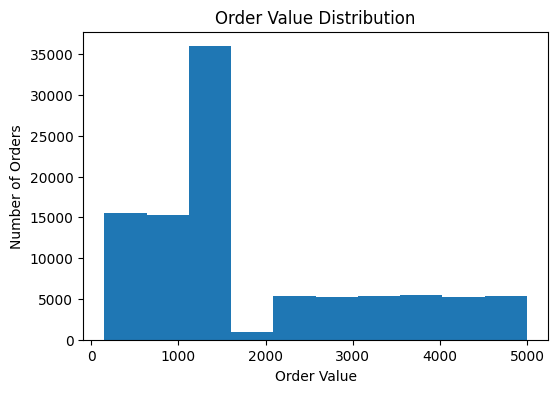

In [602]:
#Order Value Distribution
plt.figure(figsize=(6,4))
plt.hist(df["Order_Value"], bins=10)
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.title("Order Value Distribution")
plt.show()


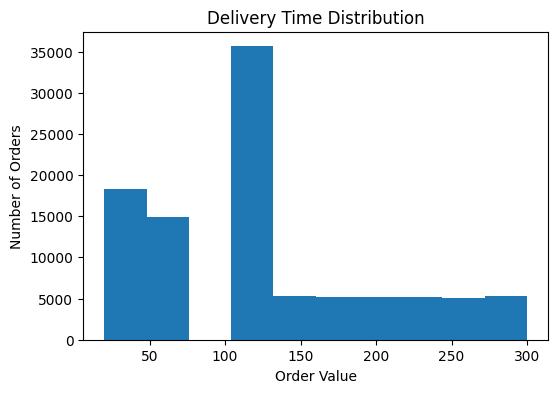

In [603]:
#Delivery Time Distribution"
plt.figure(figsize=(6,4))
plt.hist(df["Delivery_Time_Min"], bins=10)
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.title("Delivery Time Distribution")
plt.show()

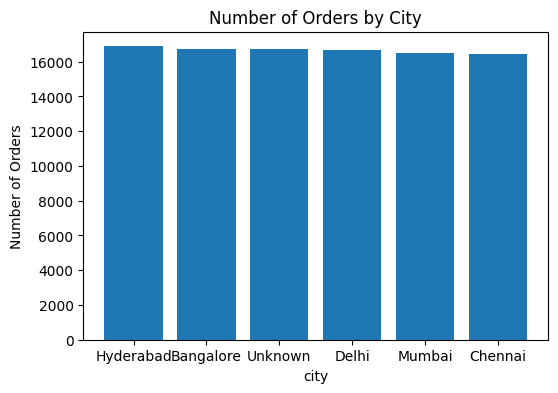

In [604]:
## City-wise Order Analysis

city_orders = df["City"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(city_orders.index, city_orders.values)
plt.xlabel("city")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by City")
plt.show()

In [605]:
# Cuisine-wise Order Analysis

cuisine_orders = df["Cuisine_Type"].value_counts()
print(cuisine_orders)

Cuisine_Type
Unknown    16885
Indian     16685
Arabian    16658
Chinese    16651
Mexican    16602
Italian    16519
Name: count, dtype: int64


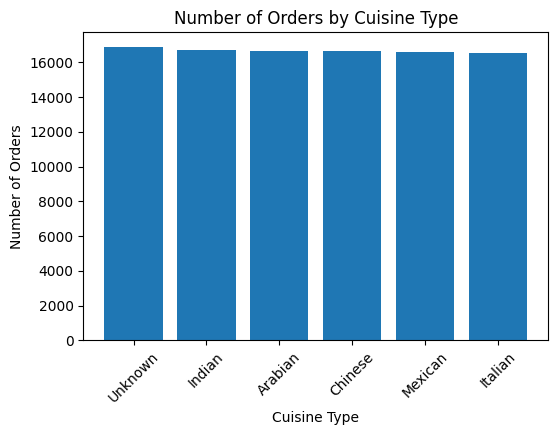

In [606]:
plt.figure(figsize= (6, 4))
plt.bar(cuisine_orders.index , cuisine_orders.values)
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.title("Number of Orders by Cuisine Type")
plt.xticks(rotation=45)
plt.show()

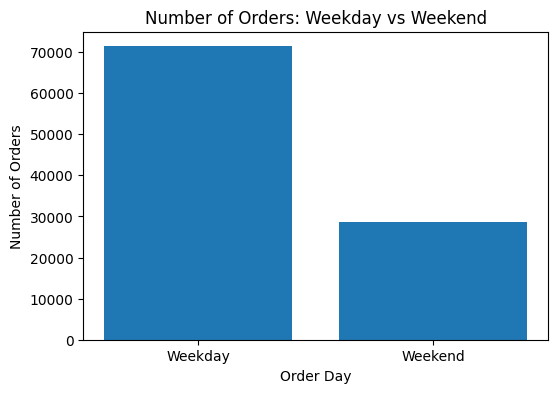

In [607]:
#Weekend vs weekday demand

plt.figure(figsize=(6, 4))
plt.bar(order_day.index, order_day.values)
plt.xlabel("Order Day")
plt.ylabel("Number of Orders")
plt.title("Number of Orders: Weekday vs Weekend")
plt.show()

In [608]:
Payment_Mode = df["Payment_Mode"].value_counts()
print(Payment_Mode)

Payment_Mode
Card       20094
Wallet     20086
COD        19977
UPI        19932
Unknown    19911
Name: count, dtype: int64


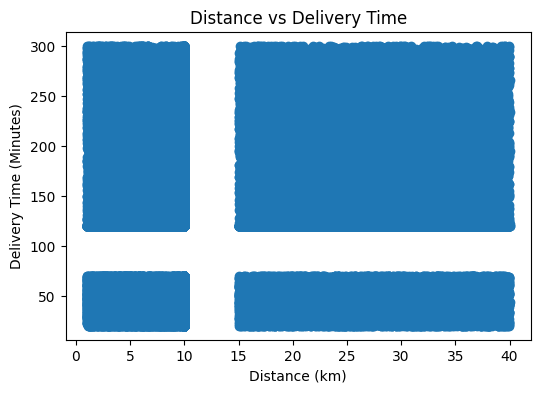

In [609]:
# Distance vs delivery delay relationship

plt.figure(figsize=(6, 4))
plt.scatter(
        df["Distance_km"],
        df["Delivery_Time_Min"]
)
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Minutes)")
plt.title("Distance vs Delivery Time")
plt.show()

In [610]:
Distance_And_time_relationship= df["Distance_km"].corr(df["Delivery_Time_Min"])
print(Distance_And_time_relationship,"No linear relationship")


0.002226501534623387 No linear relationship


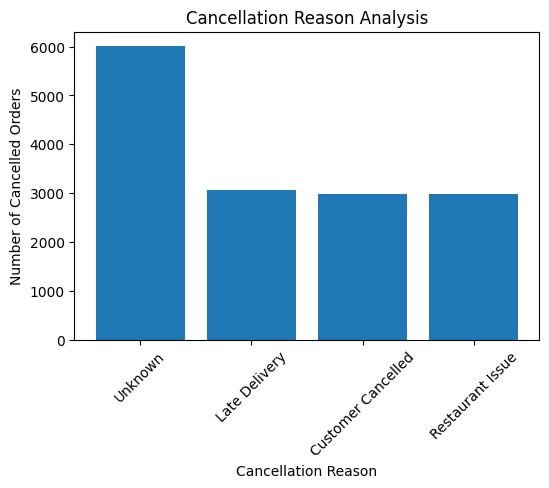

In [611]:
#Cancellation reasons analysis
Cancelled_orders = df[df["Order_Status"]== "Cancelled" ]
Cancellation_counts = Cancelled_orders["Cancellation_Reason"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(
    Cancellation_counts.index,
    Cancellation_counts.values
)
plt.xlabel("Cancellation Reason")
plt.ylabel("Number of Cancelled Orders")
plt.title("Cancellation Reason Analysis")
plt.xticks(rotation=45)
plt.show()

In [612]:
#Correlation analysis among numeric features

numeric_columns = [
    "Customer_Age",
    "Delivery_Time_Min",
    "Distance_km",
    "Order_Value",
    "Discount_Applied",
    "Final_Amount",
    "Delivery_Rating",
    "Restaurant_Rating",
    "Profit_Margin"
]

correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix.round(2))

                   Customer_Age  Delivery_Time_Min  Distance_km  Order_Value  \
Customer_Age               1.00              -0.01         -0.0        -0.00   
Delivery_Time_Min         -0.01               1.00          0.0         0.00   
Distance_km               -0.00               0.00          1.0         0.00   
Order_Value               -0.00               0.00          0.0         1.00   
Discount_Applied           0.00              -0.00          0.0         0.01   
Final_Amount              -0.00               0.00          0.0         1.00   
Delivery_Rating           -0.00               0.00         -0.0         0.00   
Restaurant_Rating          0.00               0.00          0.0        -0.00   
Profit_Margin              0.00              -0.00          0.0        -0.00   

                   Discount_Applied  Final_Amount  Delivery_Rating  \
Customer_Age                   0.00         -0.00             -0.0   
Delivery_Time_Min             -0.00          0.00          

#Feature Engineering

In [ ]:
#Order day type (Weekday / Weekend)

df["Order_Day_type"] = df["Order_Day"]
print(df["Order_Day_type"].value_counts())

Order_Day_type
Weekday    71370
Weekend    28630
Name: count, dtype: int64


In [613]:
#Peak hour indicator

df["Peak_Hour_Indicator"] = df["Peak_Hour"]
print(df["Peak_Hour_Indicator"].value_counts())


Peak_Hour_Indicator
False      33585
True       33453
Unknown    32962
Name: count, dtype: int64


In [ ]:
#Profit margin percentage
print(df["Profit_Margin"].head())

0    0.13
1    0.48
2    0.08
3    0.04
4    0.12
Name: Profit_Margin, dtype: float64


In [618]:
df["Profit_Margin_Percentage"] = df["Profit_Margin"] * 100
df["Profit_Margin_Percentage"]

0        13.0
1        48.0
2         8.0
3         4.0
4        12.0
         ... 
99995    17.0
99996   -15.0
99997    47.0
99998    44.0
99999    20.0
Name: Profit_Margin_Percentage, Length: 100000, dtype: float64

In [624]:
#Delivery performance categories
def delivery_category(time):
    if time <= 60:
        return "Fast"
    elif time <= 120:
        return "Normal"
    else:
        return "Slow"

df["Delivery_Performance"] = df["Delivery_Time_Min"].apply(delivery_category)

print(df["Delivery_Performance"].value_counts())

Delivery_Performance
Normal    40141
Slow      33246
Fast      26613
Name: count, dtype: int64


In [625]:
#Customer age groups
df["Age_Group"] = pd.cut(
    df["Customer_Age"],
    bins=[17, 25, 35, 45, 60],
    labels=["18-25", "26-35", "36-45", "46-60"]
)

print(df["Age_Group"].value_counts())

Age_Group
36-45    61715
46-60    17386
26-35    11653
18-25     9246
Name: count, dtype: int64
